# Detecting R-Peaks

1. Data Acquisition
2. Preprocessing with Wavelet Transform
3. QRS Region Detection
4. Detection or R-peaks
5. Performance Evaluation
6. Validation & Optimization

## 1. Data Adquisition

- Obtain the **MIT-BIH Arrhythmia Database**:
- Download from PhysioNet (https://physionet.org/content/mitdb/).
- Select the Lead-MLII signals for the selected records (e.g., records #100, #101, #103, etc.).
- Extract 30-minute segments for analysis, as done in the paper.

The MIT-BIH database records come in triplets: a header file (.hea), a binary signal file (.dat), and an annotation file (.atr). The wfdb library reads these together automatically.

Xia et al. specifically used the MLII (Lead II) signal for their evaluation.

In [118]:
import wfdb
import numpy as np

FILE = '100'

# The rdrecord function only needs the ID number, not the extension
record = wfdb.rdrecord('databases/mit-bih-arrhythmia-database-1.0.0/' + FILE)
annotation = wfdb.rdann('databases/mit-bih-arrhythmia-database-1.0.0/' + FILE, 'atr')

# Extract the MLII lead. Usually, it's the first channel (index 0)
# MIT-BIH signals are sampled at 360 Hz
if 'MLII' in record.sig_name:
    channel_index = record.sig_name.index('MLII')
    ecg = record.p_signal[:, channel_index]
    fs  = record.fs # sampling frequency = 360 Hz for MIT-BIH

print(np.unique(annotation.symbol, return_counts=True))

(array(['+', 'A', 'N', 'V'], dtype='<U1'), array([   1,   33, 2239,    1], dtype=int64))


If the sampling rate (frequency) was different we need to change some things:

 ```python
fs = 360  # your sampling rate

for level in range(1, 9):
    low  = fs / 2**(level+1)
    high = fs / 2**level
    print(f"Level {level} detail: {low:.1f} - {high:.1f} Hz")
```

Signal length:     650000 samples
Duration:          1805.6 seconds (30.1 minutes)
Sampling rate:     360 Hz
Amplitude range:   -2.715 to 1.435 mV
Annotated R-peaks: 2273 beats
Mean heart rate:   75.5 BPM


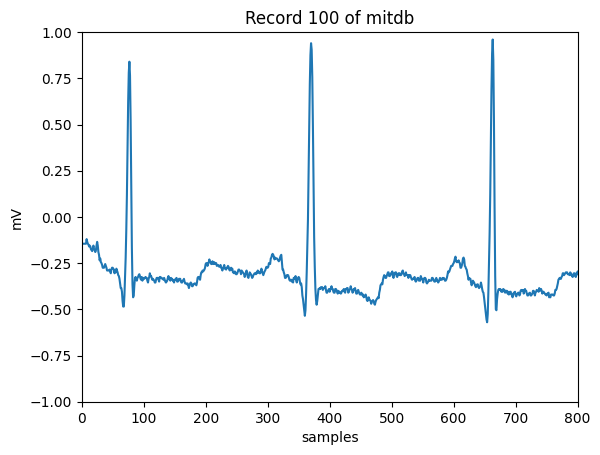

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# True R-peaks: keep only beat annotations (same rule used in all-record evaluation)
beat_types = set('NLRBaAJSVrFejnE/fQ')
beat_idx = [i for i, s in enumerate(annotation.symbol) if s in beat_types]
r_peaks_true = annotation.sample[beat_idx]

print(f"Signal length:     {len(ecg)} samples")
print(f"Duration:          {len(ecg)/fs:.1f} seconds ({len(ecg)/fs/60:.1f} minutes)")
print(f"Sampling rate:     {fs} Hz")
print(f"Amplitude range:   {ecg.min():.3f} to {ecg.max():.3f} mV")
print(f"Annotated R-peaks: {len(r_peaks_true)} beats")
print(f"Mean heart rate:   {len(r_peaks_true)/(len(ecg)/fs/60):.1f} BPM")

plt.plot(ecg)
plt.axis([0,800,-1,1]) # Just some samples
plt.xlabel('samples')
plt.ylabel('mV')
plt.title('Record 100 of mitdb')
plt.show()

### R-Peaks from Annotations

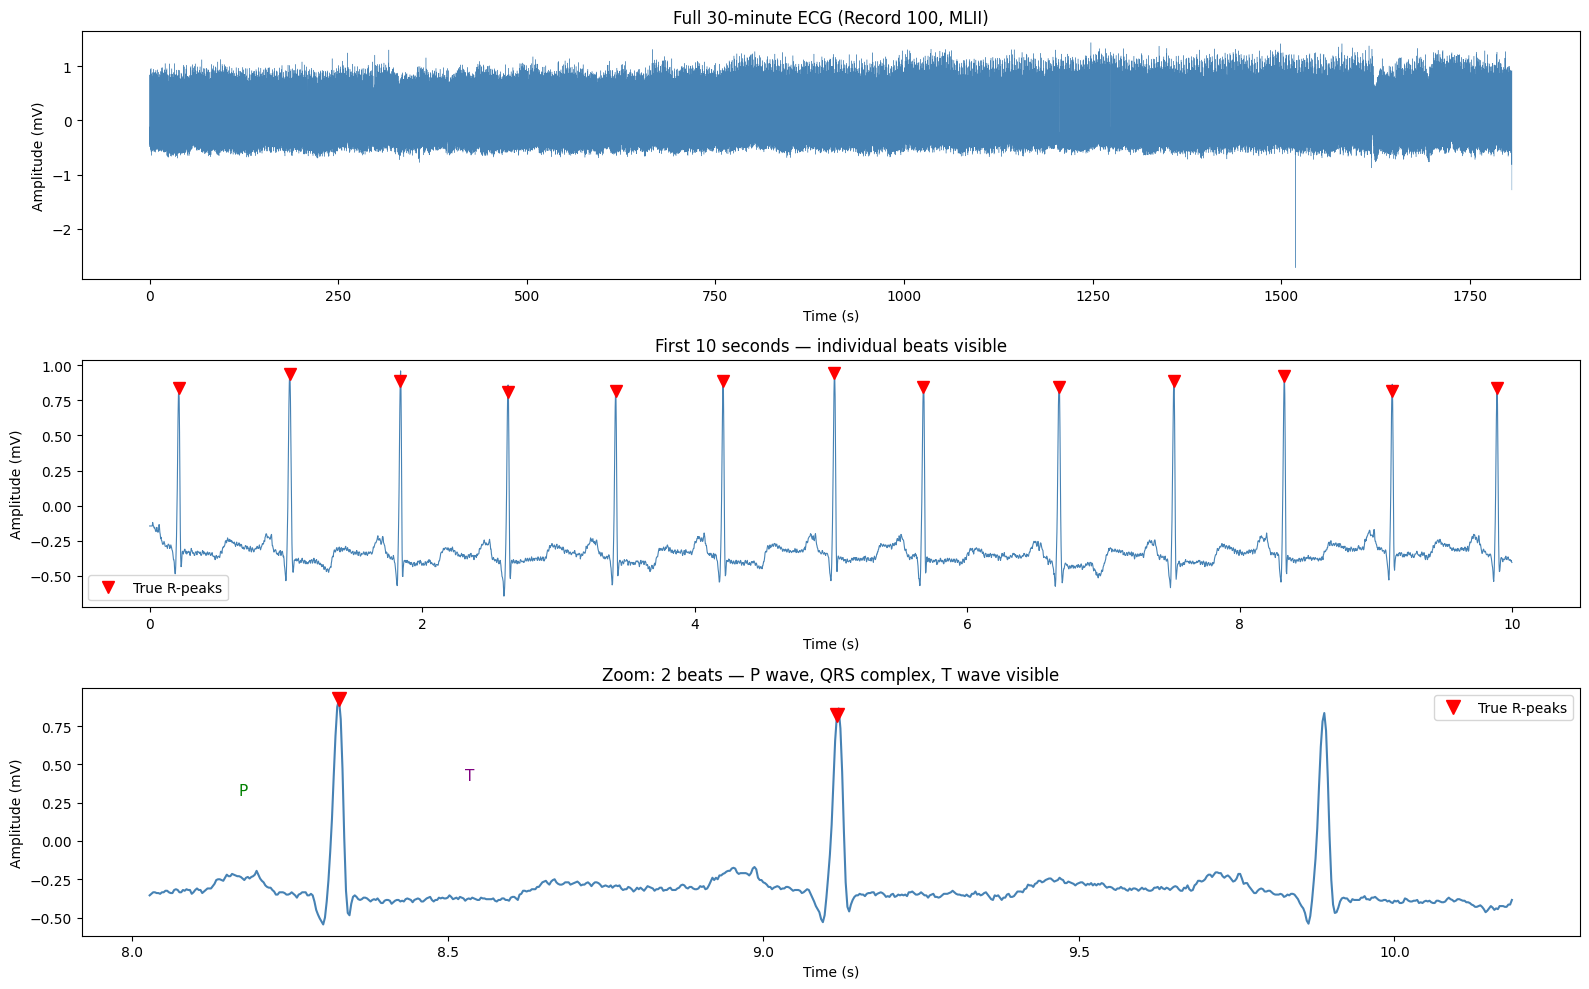

In [120]:
time = np.arange(len(ecg)) / fs  # convert samples → seconds

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Full signal overview
axes[0].plot(time, ecg, 'steelblue', linewidth=0.3)
axes[0].set_title('Full 30-minute ECG (Record ' + FILE + ', MLII)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (mV)')

# First 10 seconds — you can see individual beats clearly
mask_10s = time < 10
axes[1].plot(time[mask_10s], ecg[mask_10s], 'steelblue', linewidth=0.8)
axes[1].plot(r_peaks_true[r_peaks_true < 10*fs] / fs,
             ecg[r_peaks_true[r_peaks_true < 10*fs]],
             'rv', markersize=8, label='True R-peaks')
axes[1].set_title('First 10 seconds — individual beats visible')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend()

# Zoom into 2 beats — see P, QRS, T waves
start_sample = r_peaks_true[10] - int(0.3 * fs)  # 300ms before beat 10
end_sample   = r_peaks_true[12] + int(0.3 * fs)  # 300ms after beat 12
zoom_time    = np.arange(start_sample, end_sample) / fs
axes[2].plot(zoom_time, ecg[start_sample:end_sample], 'steelblue', linewidth=1.5)
axes[2].plot(r_peaks_true[10:12] / fs,
             ecg[r_peaks_true[10:12]],
             'rv', markersize=10, label='True R-peaks')
axes[2].set_title('Zoom: 2 beats — P wave, QRS complex, T wave visible')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].legend()

# Annotate P, QRS, T on the zoomed view
beat_time = r_peaks_true[10] / fs
axes[2].annotate('P', xy=(beat_time - 0.16, 0.3), fontsize=11, color='green')
axes[2].annotate('QRS', xy=(beat_time - 0.02, 1.1), fontsize=11, color='red')
axes[2].annotate('T', xy=(beat_time + 0.2, 0.4), fontsize=11, color='purple')

plt.tight_layout()
plt.show()

You can clearly see the morphology — the QRS is sharp and narrow, T wave is the broader bump after, and P wave is the small one before. The annotations capture the R-peaks well. Notice T waves (~0.1-0.2 mV) are much smaller than R-peaks (~0.8 mV) here, which is good — this record will be relatively easy to detect.


### Frequency Plot (Furious Transform)

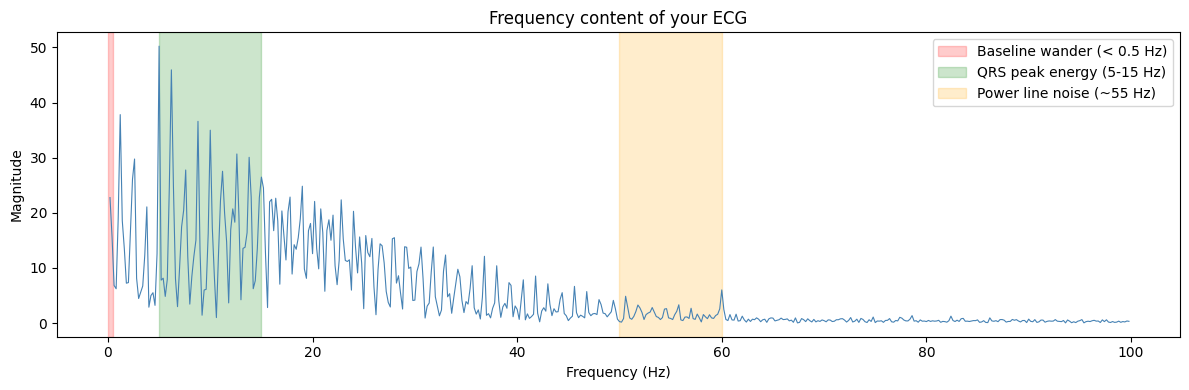

In [121]:
from scipy.fft import fft, fftfreq

segment = ecg[:5*fs]
fft_vals = np.abs(fft(segment))
freqs    = fftfreq(len(segment), d=1/fs)

pos_mask = (freqs > 0) & (freqs < 100)

plt.figure(figsize=(12, 4))
plt.plot(freqs[pos_mask], fft_vals[pos_mask], 'steelblue', linewidth=0.8)
plt.axvspan(0,  0.5, alpha=0.2, color='red',    label='Baseline wander (< 0.5 Hz)')
plt.axvspan(5,  15,  alpha=0.2, color='green',  label='QRS peak energy (5-15 Hz)')
plt.axvspan(50, 60,  alpha=0.2, color='orange', label='Power line noise (~55 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency content of your ECG')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Preprocessing with Wavelet Transform

- Choose the Sym8 wavelet (as used in the paper).
- Perform discrete wavelet decomposition at level 8.
- Extract the approximation coefficients at level 8 (cA8) and detail coefficients (cD1-cD3).
- Reconstruct the filtered ECG signal using these coefficients, effectively removing baseline drift and noise.

Following the paper's method, you must decompose the signal to **level 8** using the Sym8 wavelet. You then reconstruct the "filtered" signal by removing specific noise-heavy components.

- **Remove $cA_8$:** Eliminates baseline drift.
- **Remove $cD_1, cD_2$:** Eliminates high-frequency industrial noise.

### Wavelet Decomposition

In [122]:
import pywt

start = r_peaks_true[10]    # Starting from beat 10 so we have good beats
end   = start + 5 * fs      # For 5 seconds
segment = ecg[start:end]
seg_time = np.arange(len(segment)) / fs

# Decompose with sym8 wavelet at 8 levels
wavelet = 'sym8'
level   = 8
fs = 360
coeffs  = pywt.wavedec(segment, wavelet, level=level)

# Print the actual frequency bands before doing anything
def print_wavelet_bands(fs, level):
    nyquist = fs / 2
    print(f"\nWavelet bands for fs={fs}Hz, {level} levels:")
    print(f"  cA{level}: 0.00 - {nyquist/2**level:.2f} Hz  ← approximation")
    for n in range(level, 0, -1):
        low  = nyquist / 2**n
        high = nyquist / 2**(n-1)
        print(f"  cD{n}: {low:.2f} - {high:.2f} Hz  "
              f"(coeffs index {level-n+1})")

print_wavelet_bands(fs=fs, level=level)


Wavelet bands for fs=360Hz, 8 levels:
  cA8: 0.00 - 0.70 Hz  ← approximation
  cD8: 0.70 - 1.41 Hz  (coeffs index 1)
  cD7: 1.41 - 2.81 Hz  (coeffs index 2)
  cD6: 2.81 - 5.62 Hz  (coeffs index 3)
  cD5: 5.62 - 11.25 Hz  (coeffs index 4)
  cD4: 11.25 - 22.50 Hz  (coeffs index 5)
  cD3: 22.50 - 45.00 Hz  (coeffs index 6)
  cD2: 45.00 - 90.00 Hz  (coeffs index 7)
  cD1: 90.00 - 180.00 Hz  (coeffs index 8)


C:\Users\isabe\AppData\Roaming\Python\Python312\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 8 is too high: all coefficients will experience boundary effects.
  warnings.warn(


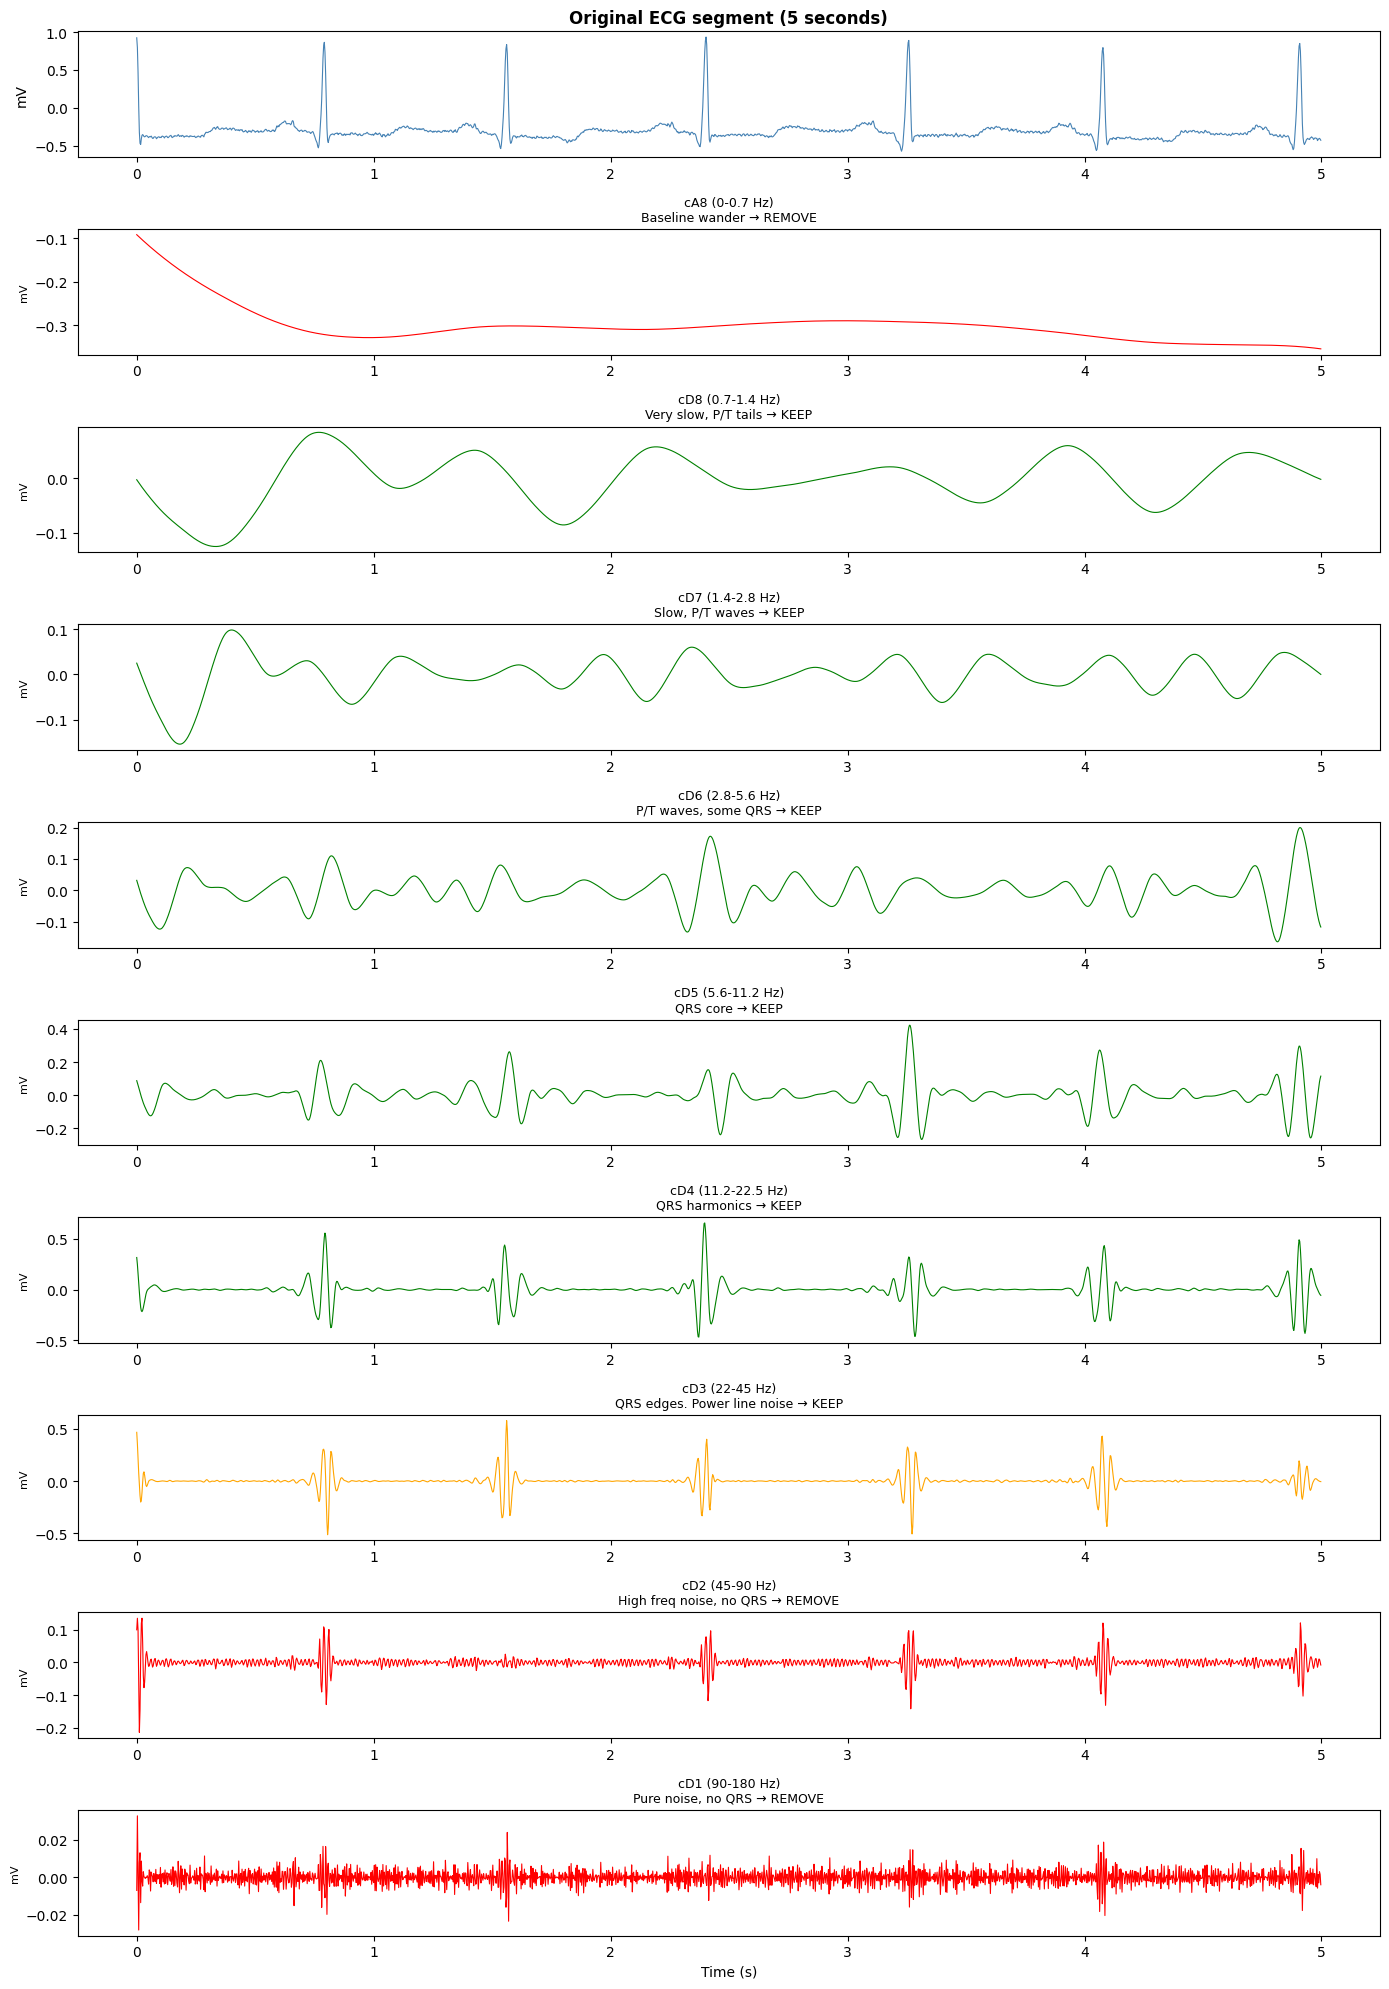

In [123]:
# Plot each level individually
fig, axes = plt.subplots(10, 1, figsize=(14, 20))

# Original signal
axes[0].plot(seg_time, segment, 'steelblue', linewidth=0.8)
axes[0].set_title('Original ECG segment (5 seconds)', fontweight='bold')
axes[0].set_ylabel('mV')

# Reconstruct each level individually to see its contribution
level_names = ['cA8 (0-0.7 Hz)\nBaseline wander → REMOVE',
               'cD8 (0.7-1.4 Hz)\nVery slow, P/T tails → KEEP',
               'cD7 (1.4-2.8 Hz)\nSlow, P/T waves → KEEP',
               'cD6 (2.8-5.6 Hz)\nP/T waves, some QRS → KEEP',
               'cD5 (5.6-11.2 Hz)\nQRS core → KEEP',
               'cD4 (11.2-22.5 Hz)\nQRS harmonics → KEEP',
               'cD3 (22-45 Hz)\nQRS edges. Power line noise → KEEP',
               'cD2 (45-90 Hz)\nHigh freq noise, no QRS → REMOVE',
               'cD1 (90-180 Hz)\nPure noise, no QRS → REMOVE']

colors = ['red', 'green', 'green', 'green', 'green',
          'green', 'orange', 'red', 'red']

for i, (name, color) in enumerate(zip(level_names, colors)):
    # Reconstruct signal from ONLY this level
    zero_coeffs = [np.zeros_like(c) for c in coeffs]
    zero_coeffs[i] = coeffs[i]
    reconstructed = pywt.waverec(zero_coeffs, wavelet)[:len(segment)]
    
    axes[i+1].plot(seg_time, reconstructed, color=color, linewidth=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('mV', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### Reconstruct the clean signal

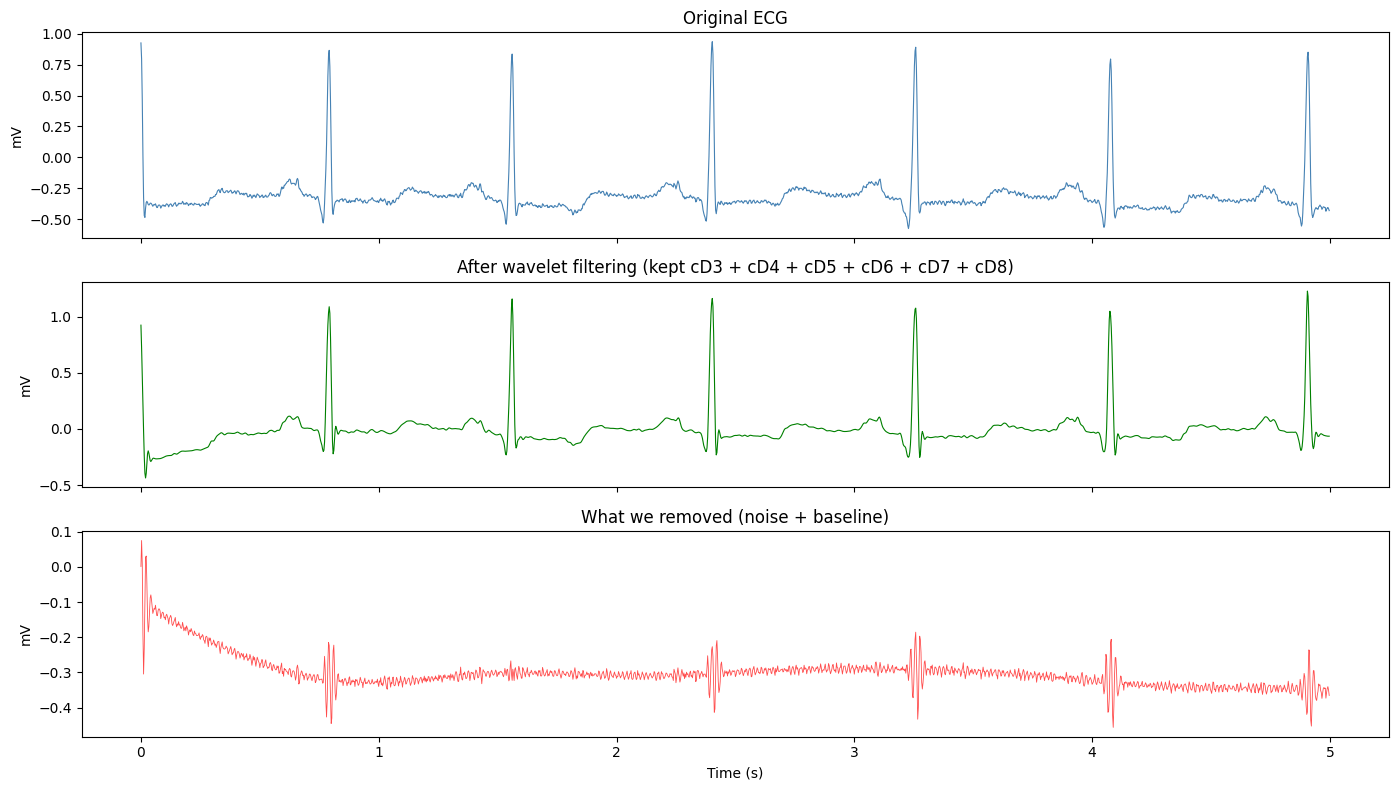

In [124]:
keep_levels = [1, 2, 3, 4, 5, 6]  # cD8 through cD3

clean_coeffs = [np.zeros_like(c) for c in coeffs]

for k in keep_levels:
    clean_coeffs[k] = coeffs[k]

clean_signal = pywt.waverec(clean_coeffs, wavelet)[:len(segment)]

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(seg_time, segment, 'steelblue', linewidth=0.8)
axes[0].set_title('Original ECG')
axes[0].set_ylabel('mV')

axes[1].plot(seg_time, clean_signal, 'green', linewidth=0.8)
axes[1].set_title('After wavelet filtering (kept cD3 + cD4 + cD5 + cD6 + cD7 + cD8)')
axes[1].set_ylabel('mV')

axes[2].plot(seg_time, segment - clean_signal, 'red', linewidth=0.6, alpha=0.7)
axes[2].set_title('What we removed (noise + baseline)')
axes[2].set_ylabel('mV')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 3. QRS Region Detection with K-Means

Unlike traditional methods that find R-peaks first, this method extracts the **QRS region** first using slope information.

- **Calculate Slope**: Determine the absolute slope between adjacent points (for each data point):

$$
abs\_slope = |data(k+1) - data(k)|
$$

- **Segment the Data**: Divide the signal into **1-minute segments** to ensure clustering accuracy.
- Apply **K-means clustering** (with K=2) on the absolute slope values within each segment.
By clustering these absolute slopes into two groups, you separate the "high-activity" QRS regions from the "low-activity" baseline.
- The algorithm will group slopes into two clusters: one for the high-intensity fluctuations of the QRS complex and one for the lower-intensity "background" waves.
- Points belonging to the higher-slope cluster are identified as part of the QRS region. Identify the cluster with higher slope values as corresponding to QRS complexes.

### Abosulte Slope

`np.gradient()` computes the slope at every sample using the samples on both sides, and crucially **never changes the array length**. The formula it uses internally is:

$$
gradient[k] = (data[k+1] - data[k-1]) / 2
$$

This is slightly smoother than np.diff() because it looks both forward and backward instead of only forward. For ECG slope computation it gives marginally better results.

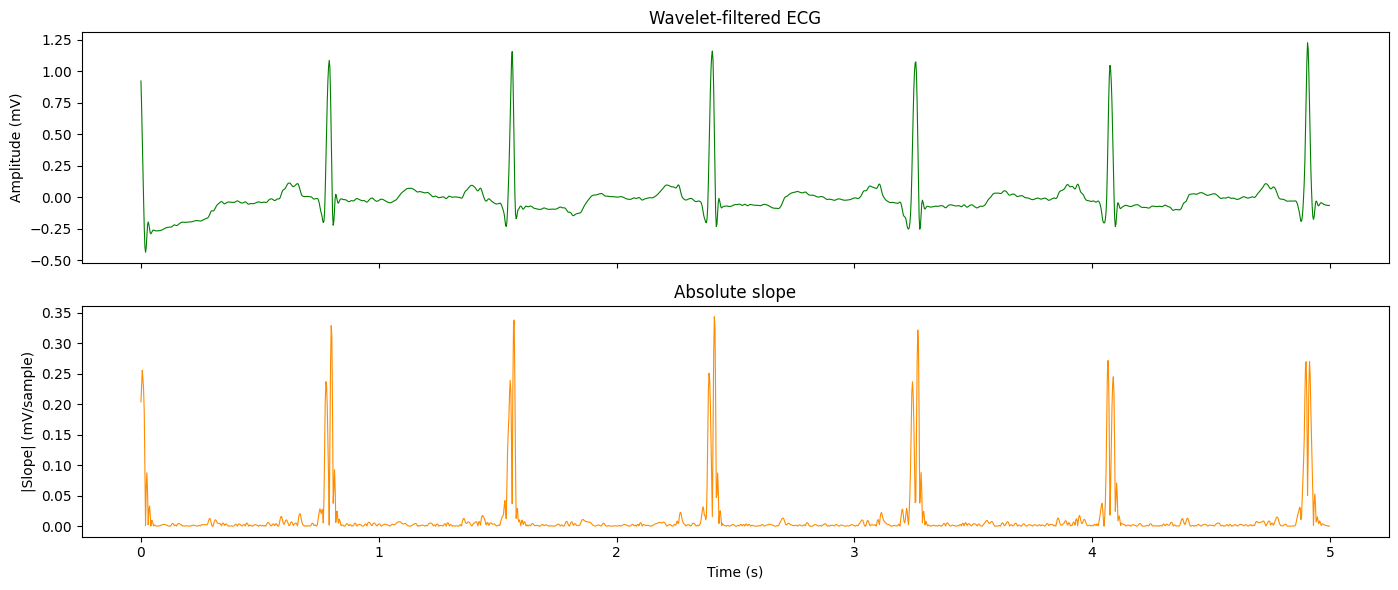

In [125]:
# The slope between adjacent samples
abs_slope = np.abs(np.gradient(clean_signal))

# Plot clean signal and absolute slope
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(seg_time, clean_signal, 'green', linewidth=0.8)
axes[0].set_title('Wavelet-filtered ECG')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(seg_time, abs_slope, 'darkorange', linewidth=0.8)
axes[1].set_title('Absolute slope')
axes[1].set_ylabel('|Slope| (mV/sample)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### Segmented K-Means

First we need to preprocess again, but this time the whole data, as well as the absolute slope.

After that is done, we can then apply the segmented k-means.

1. We prepare the data for the loop, we will do it in 1-minute segments (so 30 times). 
If you cluster all 30 minutes together, the high-slope cluster centroid gets pulled toward the large-amplitude beats in minute 20. The quieter beats in minute 1 might fall below the global decision boundary and get missed entirely.
By running K-Means on **1-minute segments independently**, each segment gets its own two centroids calibrated to the local amplitude. The algorithm adapts automatically.

2. In the loop, each segment will compute the kmeans (A brand new K-Means is fitted independently on each minute's slope values). Each row is one "observation" for K-Means. 
Since our feature is just one number (the slope value), each observation has only 1 column. K-Means runs on just these 21,600 samples and assigns each one a label — either 0 or 1 (if it's inside the QRS or not). It finds two centroids.

Signal polarity: positive


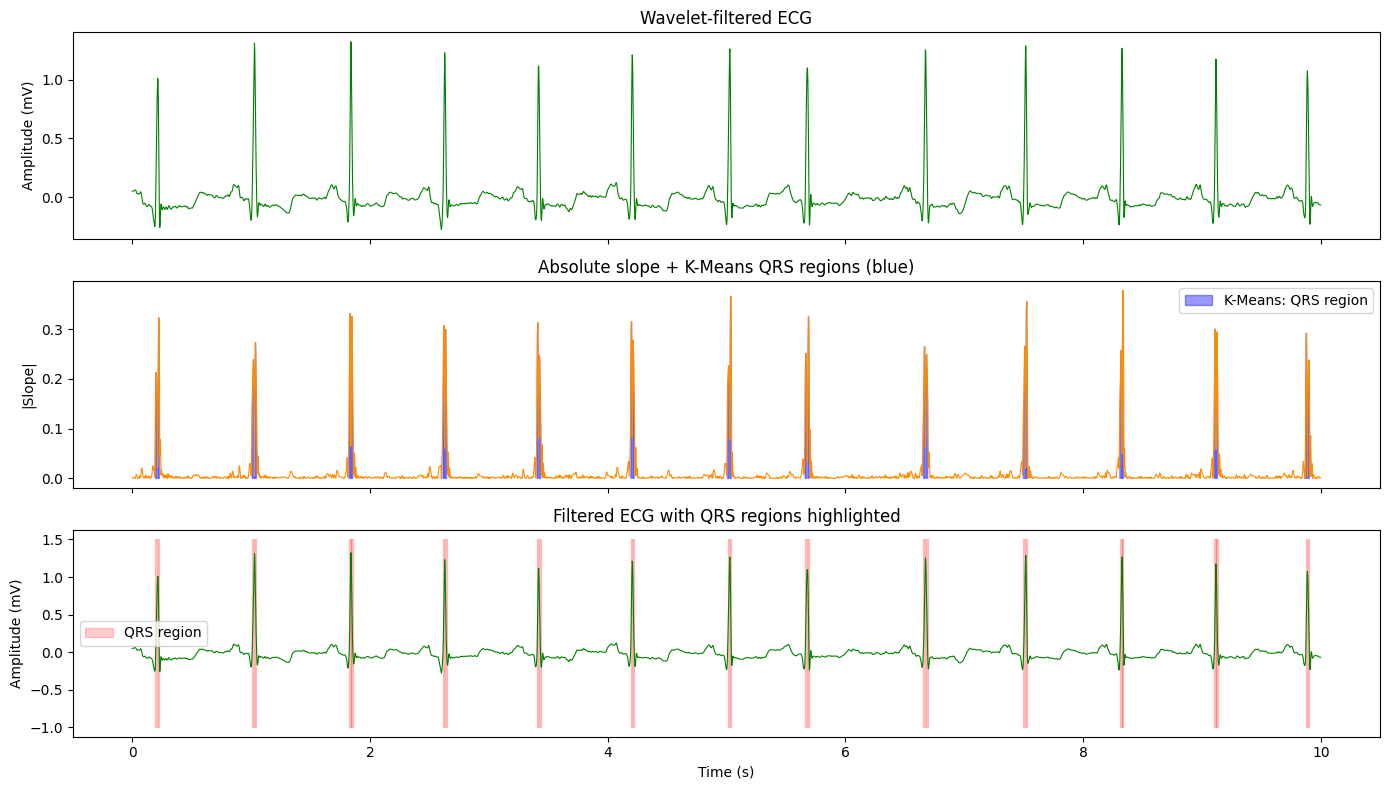

In [126]:
from sklearn.cluster import KMeans

# Wavelet filter applied to full ECG
full_coeffs = pywt.wavedec(ecg, wavelet='sym8', level=8)
full_clean_coeffs = [np.zeros_like(c) for c in full_coeffs]
for k in [1, 2, 3, 4, 5, 6]:  # cD8 through cD3
    full_clean_coeffs[k] = full_coeffs[k]
full_clean = pywt.waverec(full_clean_coeffs, wavelet='sym8')[:len(ecg)]

# Polarity detection
reference_window = full_clean[:10 * fs]          # first 10 seconds
pos_peak = np.max(reference_window)              # strongest positive deflection
neg_peak = np.abs(np.min(reference_window))      # strongest negative deflection
polarity  = 1 if pos_peak >= neg_peak else -1    # +1 = normal, -1 = inverted
full_clean = full_clean * polarity               # flip if inverted

print(f"Signal polarity: {'positive' if polarity == 1 else 'negative'}")

# Absolute slope
full_abs_slope = np.abs(np.gradient(full_clean))

# Segmented K-Means
segment_len = int(1 * 60 * fs)      # 1 minute = 21,600 samples -> adaptive to slow amplitude drift
n = len(full_abs_slope)             # total samples in 30-min signal = 648,000
qrs_mask = np.zeros(n, dtype=bool)  # start with everything labelled False

for start in range(0, n, segment_len):
    end = min(start + segment_len, n)
    seg = full_abs_slope[start:end].reshape(-1, 1) # converts it from a flat list to a column. From (21600,) to (21600, 1)
    
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = kmeans.fit_predict(seg)

    # Identify which cluster is QRS (higher centroid = higher slope = QRS)
    centers_flat    = kmeans.cluster_centers_.flatten() # the flatten() gives you the actual centroid VALUES, and argmax() the index of the highest value
    qrs_cluster     = np.argmax(centers_flat)
    nonqrs_cluster  = 1 - qrs_cluster

    # Diagnostics
    minute    = start // segment_len
    threshold = (centers_flat[qrs_cluster] + centers_flat[nonqrs_cluster]) / 2
    n_qrs     = (labels == qrs_cluster).sum()
    
    # print(f"Minute {minute:2d}: "
    #       f"non-QRS centroid={centers_flat[nonqrs_cluster]:.4f}, "
    #       f"QRS centroid={centers_flat[qrs_cluster]:.4f}, "
    #       f"threshold={threshold:.4f}, "
    #       f"QRS samples={n_qrs}")

    # Write QRS labels into the full mask
    qrs_mask[start:end] = (labels == qrs_cluster)

# Visualise first 10 seconds
show_samples = 10 * fs
show_time    = np.arange(show_samples) / fs

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(show_time, full_clean[:show_samples], 'green', linewidth=0.8)
axes[0].set_title('Wavelet-filtered ECG')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(show_time, full_abs_slope[:show_samples], 'darkorange', linewidth=0.8)
axes[1].fill_between(show_time, 0, full_abs_slope[:show_samples],
                     where=qrs_mask[:show_samples],
                     color='blue', alpha=0.4, label='K-Means: QRS region')
axes[1].set_title('Absolute slope + K-Means QRS regions (blue)')
axes[1].set_ylabel('|Slope|')
axes[1].legend()

axes[2].plot(show_time, full_clean[:show_samples], 'green', linewidth=0.8)
axes[2].fill_between(show_time, -1, 1.5,
                     where=qrs_mask[:show_samples],
                     color='red', alpha=0.2, label='QRS region')
axes[2].set_title('Filtered ECG with QRS regions highlighted')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

plt.tight_layout()
plt.show()

Each QRS creates a rising edge spike AND a falling edge spike. If there's a tiny gap between them where the slope briefly dips below the threshold, K-Means splits them into two separate regions instead of one.


#### Visualising It Sample by Sample

Here's a zoomed view of exactly one QRS complex to make it concrete:

In [127]:
# # Zoom into a single beat to see sample-by-sample detail
# beat_idx = r_peaks_true[15]             # pick beat number 15
# window   = int(0.3 * fs)               # 300ms either side

# start = beat_idx - window
# end   = beat_idx + window
# zoom_time    = np.arange(start, end) / fs
# zoom_signal  = full_clean[start:end]
# zoom_slope   = full_abs_slope[start:end]

# fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# # Panel 1: the filtered signal
# axes[0].plot(zoom_time, zoom_signal, 'green', linewidth=1.5)
# axes[0].axvline(beat_idx/fs, color='red', linestyle='--', 
#                 alpha=0.5, label='True R-peak')
# axes[0].scatter(zoom_time, zoom_signal, s=8, color='green', zorder=5)
# axes[0].set_title('Filtered ECG — one beat (dots = individual samples)')
# axes[0].set_ylabel('Amplitude (mV)')
# axes[0].legend()

# # Panel 2: the raw slope (before abs) to see +/- 
# raw_slope_zoom = np.diff(full_clean[start:end])
# raw_slope_zoom = np.append(raw_slope_zoom, raw_slope_zoom[-1])
# axes[1].plot(zoom_time, raw_slope_zoom, 'purple', linewidth=1.2)
# axes[1].axhline(0, color='black', linewidth=0.5)
# axes[1].axvline(beat_idx/fs, color='red', linestyle='--', alpha=0.5)
# axes[1].set_title('Raw slope s[k] = x[k+1] - x[k]   (positive=rising, negative=falling)')
# axes[1].set_ylabel('Slope (mV/sample)')

# # Panel 3: absolute slope
# axes[2].plot(zoom_time, zoom_slope, 'darkorange', linewidth=1.2)
# axes[2].fill_between(zoom_time, 0, zoom_slope, alpha=0.3, color='orange')
# axes[2].axvline(beat_idx/fs, color='red', linestyle='--', alpha=0.5)
# axes[2].set_title('Absolute slope |s[k]|   (both edges folded positive)')
# axes[2].set_ylabel('|Slope| (mV/sample)')
# axes[2].set_xlabel('Time (s)')

# plt.tight_layout()
# plt.show()

### R-Peak Extraction

In [128]:
# 1. Convert mask to list of (start, end) regions 
def extract_regions(mask, fs, min_ms=20, max_ms=200):
    """
    Find contiguous True runs in the mask.
    Filter out regions that are too short (noise) or too long (merged beats).
    """
    min_samples = int(min_ms / 1000 * fs)
    max_samples = int(max_ms / 1000 * fs)

    regions  = []
    in_region = False
    start     = 0

    for i, val in enumerate(mask):
        if val and not in_region:       # region starts
            start     = i
            in_region = True
        elif not val and in_region:     # region ends
            duration = i - start
            if min_samples <= duration <= max_samples:
                regions.append((start, i))
            in_region = False

    # Handle region at the very end of signal
    if in_region:
        duration = len(mask) - start
        if min_samples <= duration <= max_samples:
            regions.append((start, len(mask)))

    return regions


# 2. Find maximum amplitude sample within each region
def detect_r_peaks(signal, regions):
    """
    Within each QRS region, the R-peak is the sample
    with the highest amplitude.
    """
    r_peaks = []
    for start, end in regions:
        segment      = signal[start:end]
        peak_in_seg  = np.argmax(segment)      # index within segment
        r_peaks.append(start + peak_in_seg)    # convert to full signal index
    return np.array(r_peaks)


# 3. Refractory period filter 
def apply_refractory(peaks, signal, fs, refractory_ms=200):
    """
    Enforce minimum time between consecutive detections.
    200ms = physiological minimum RR interval.
    If two detections are closer than this, keep the
    one with the higher amplitude and discard the other.
    """
    if len(peaks) == 0:
        return peaks

    refractory_samples = int(refractory_ms / 1000 * fs)  # 72 samples
    filtered = [peaks[0]]

    for peak in peaks[1:]:
        if peak - filtered[-1] >= refractory_samples:
            # Far enough from last detection → keep it
            filtered.append(peak)
        else:
            # Too close → keep whichever has higher amplitude
            if signal[peak] > signal[filtered[-1]]:
                filtered[-1] = peak   # replace with higher one

    return np.array(filtered)


# Run all three sub-steps
regions        = extract_regions(qrs_mask, fs, min_ms=10, max_ms=200)
r_peaks_raw    = detect_r_peaks(full_clean, regions)
r_peaks_detect = apply_refractory(r_peaks_raw, full_clean, fs, 150)

print(f"QRS regions found:          {len(regions)}")
print(f"R-peaks before refractory:  {len(r_peaks_raw)}")
print(f"R-peaks after refractory:   {len(r_peaks_detect)}")
print(f"True annotated beats:       {len(r_peaks_true)}")
print(f"Difference:                 {len(r_peaks_detect) - len(r_peaks_true):+d}")

QRS regions found:          4548
R-peaks before refractory:  4548
R-peaks after refractory:   2273
True annotated beats:       2273
Difference:                 +0


Visualization:

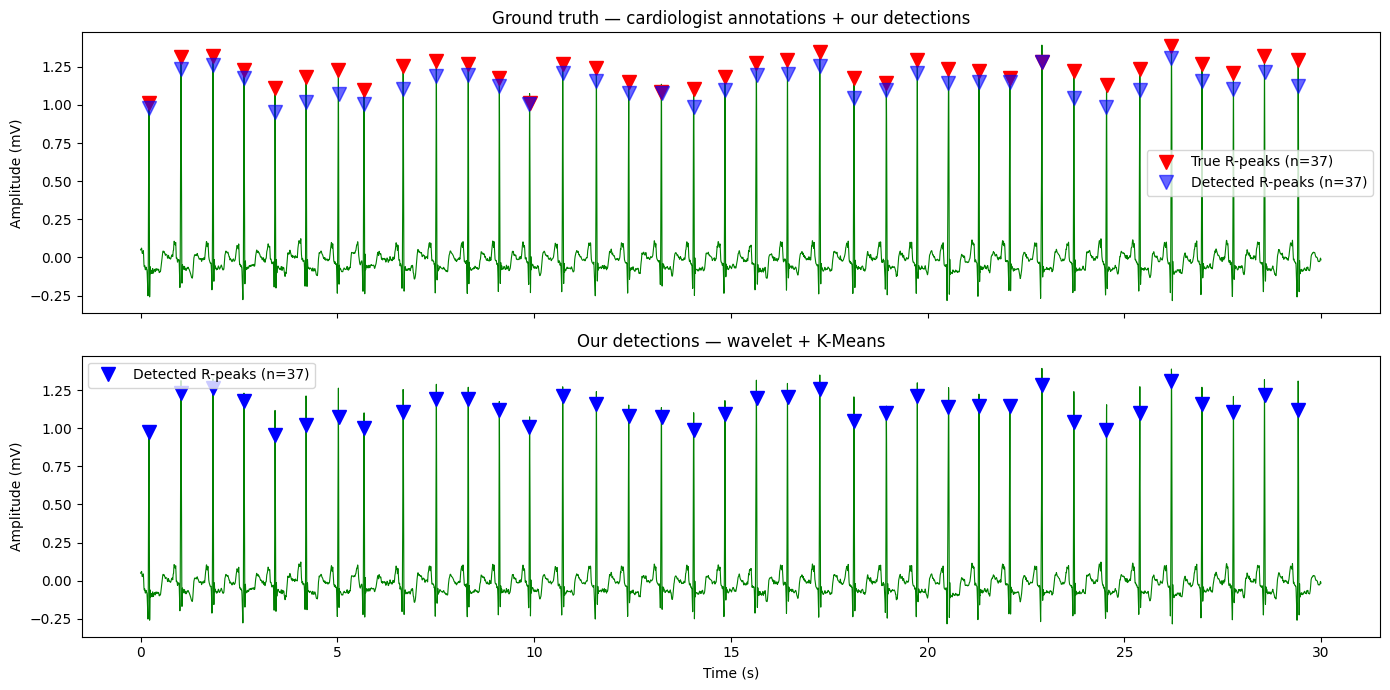

In [129]:
# Compare detected vs true on 30 seconds
show  = 30 * fs
t     = np.arange(show) / fs

# Get detections and true peaks in this window
det_in_window  = r_peaks_detect[r_peaks_detect < show]
true_in_window = r_peaks_true[r_peaks_true < show]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: true annotations
axes[0].plot(t, full_clean[:show], 'green', linewidth=0.8)
axes[0].plot(true_in_window / fs,
             full_clean[true_in_window],
             'rv', markersize=10, label=f'True R-peaks (n={len(true_in_window)})')
axes[0].plot(det_in_window / fs,
             full_clean[det_in_window],
             'bv', markersize=10, label=f'Detected R-peaks (n={len(det_in_window)})', alpha=0.6)
axes[0].set_title('Ground truth — cardiologist annotations + our detections')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend()

# Panel 2: our detections
axes[1].plot(t, full_clean[:show], 'green', linewidth=0.8)
axes[1].plot(det_in_window / fs,
             full_clean[det_in_window],
             'bv', markersize=10, label=f'Detected R-peaks (n={len(det_in_window)})')
axes[1].set_title('Our detections — wavelet + K-Means')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()

plt.tight_layout()
plt.show()

True formal evaluation:

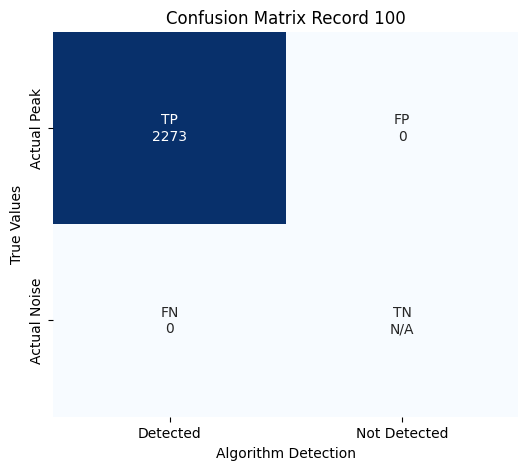

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate(detected, ground_truth, fs, tolerance_ms=150):
    tolerance = int(tolerance_ms / 1000 * fs)
    matched   = set()
    tp = fp   = 0

    for det in detected:
        dists   = np.abs(ground_truth - det)
        closest = np.argmin(dists)
        if dists[closest] <= tolerance and closest not in matched:
            tp += 1
            matched.add(closest)
        else:
            fp += 1

    fn  = len(ground_truth) - len(matched)
    se  = 100 * tp / (tp + fn)
    ppv = 100 * tp / (tp + fp)
    f1  = 2 * se * ppv / (se + ppv)

    # print("=" * 40)
    # print(f"  TP  = {tp}")
    # print(f"  FP  = {fp}")
    # print(f"  FN  = {fn}")
    # print(f"  Sensitivity (Se):  {se:.4f}%")
    # print(f"  Pos. Predictivity: {ppv:.4f}%")
    # print(f"  F1 Score:          {f1:.4f}%")
    # print("=" * 40)

    return se, ppv, f1, tp, fp, fn

def plot_confusion_matrix(tp, fp, fn):
    # Define the matrix structure
    # Note: TN is omitted or set to 0 as it's often undefined in peak detection
    matrix = np.array([[tp, fp], 
                       [fn, 0]]) 
    
    labels = np.array([[f'TP\n{tp}', f'FP\n{fp}'], 
                       [f'FN\n{fn}', 'TN\nN/A']])

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=labels, fmt="", cmap='Blues', cbar=False,
                xticklabels=['Detected', 'Not Detected'],
                yticklabels=['Actual Peak', 'Actual Noise'])
    
    plt.title('Confusion Matrix Record ' + FILE)
    plt.xlabel('Algorithm Detection')
    plt.ylabel('True Values')
    plt.show()

se, ppv, f1, tp, fp, fn = evaluate(r_peaks_detect, r_peaks_true, fs)
plot_confusion_matrix(tp, fp, fn)

# Test all the records

Record       TP     FP     FN      Se%     PPV%      F1%
--------------------------------------------------
100        2273      0      0   100.00   100.00   100.00
101        1864      6      1    99.95    99.68    99.81
102        2186      0      1    99.95   100.00    99.98
103        2084      0      0   100.00   100.00   100.00
104        2228     62      1    99.96    97.29    98.61
105        2558     63     14    99.46    97.60    98.52
106        1981      1     46    97.73    99.95    98.83
107        2135      2      2    99.91    99.91    99.91
108        1740    173     23    98.70    90.96    94.67
109        2531      1      1    99.96    99.96    99.96
111        2121     22      3    99.86    98.97    99.41
112        2539      2      0   100.00    99.92    99.96
113        1795      0      0   100.00   100.00   100.00
114        1879      4      0   100.00    99.79    99.89
115        1953      0      0   100.00   100.00   100.00
116        2391      3     21    99.1

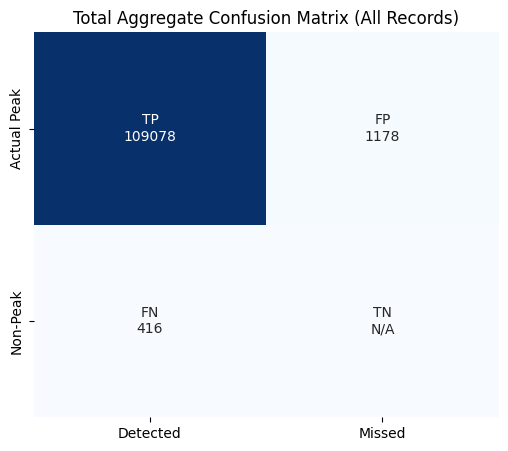

C:\Users\isabe\AppData\Local\Temp\ipykernel_22980\380677800.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='Record', y='Se', palette='Reds_r')


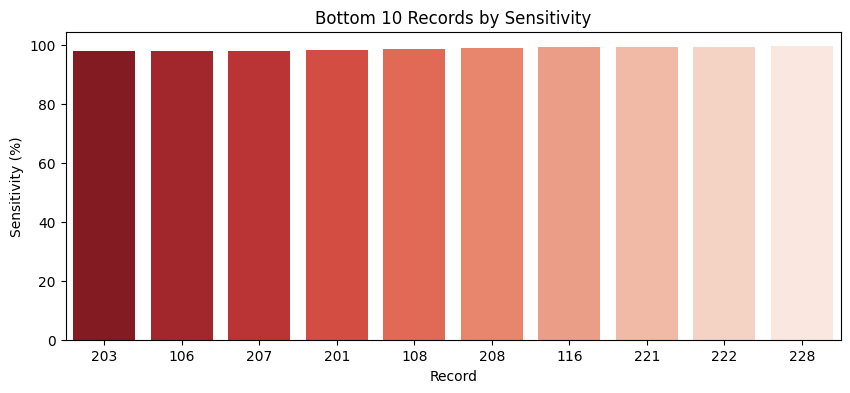


OVERALL DATABASE METRICS
Mean Se:  99.63%
Mean PPV: 98.93%
Total TP: 109078 | Total FP: 1178 | Total FN: 416


In [133]:
import wfdb
import numpy as np
import pywt
from sklearn.cluster import KMeans
import pandas as pd

# All 48 MIT-BIH record names
all_records = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

def full_pipeline(ecg, fs):
    # Wavelet filter
    coeffs       = pywt.wavedec(ecg, 'sym8', level=8)
    clean_coeffs = [np.zeros_like(c) for c in coeffs]
    for k in [1,2,3,4,5,6]:
        clean_coeffs[k] = coeffs[k]
    clean = pywt.waverec(clean_coeffs, 'sym8')[:len(ecg)]
    
    # Polarity detection
    reference_window = clean[:10 * fs]               # first 10 seconds
    pos_peak = np.max(reference_window)              # strongest positive deflection
    neg_peak = np.abs(np.min(reference_window))      # strongest negative deflection
    polarity  = 1 if pos_peak >= neg_peak else -1    # +1 = normal, -1 = inverted
    clean = clean * polarity                         # flip if inverted

    # Absolute slope
    abs_slope = np.abs(np.gradient(clean))

    # Segmented K-Means
    seg_len  = int(1 * 60 * fs)
    n        = len(abs_slope)
    mask     = np.zeros(n, dtype=bool)
    for start in range(0, n, seg_len):
        end    = min(start + seg_len, n)
        seg    = abs_slope[start:end].reshape(-1, 1)
        km     = KMeans(n_clusters=2, n_init=10, random_state=42)
        labels = km.fit_predict(seg)
        qrs_c  = np.argmax(km.cluster_centers_.flatten())
        mask[start:end] = (labels == qrs_c)

    # Extract regions
    regions   = extract_regions(mask, fs, min_ms=10, max_ms=200)
    peaks_raw = detect_r_peaks(clean, regions)
    peaks     = apply_refractory(peaks_raw, clean, fs, 250)
    return peaks

# Run on all records
total_tp = total_fp = total_fn = 0
results = []

print(f"{'Record':<8} {'TP':>6} {'FP':>6} {'FN':>6} {'Se%':>8} {'PPV%':>8} {'F1%':>8}")
print("-" * 50)

for rec in all_records:
    try:
        record     = wfdb.rdrecord('databases/mit-bih-arrhythmia-database-1.0.0/' + rec)
        annotation = wfdb.rdann('databases/mit-bih-arrhythmia-database-1.0.0/' + rec, 'atr')

        ecg_sig    = record.p_signal[:, 0]
        fs_rec     = record.fs
        true_peaks = annotation.sample

        # Only keep beat annotations (exclude noise, artifact labels)
        beat_types = set('NLRBaAJSVrFejnE/fQ')
        beat_idx   = [i for i, s in enumerate(annotation.symbol) 
                        if s in beat_types]
        true_peaks = annotation.sample[beat_idx]

        detected   = full_pipeline(ecg_sig, fs_rec)
        se, ppv, f1, tp, fp, fn = evaluate(detected, true_peaks, fs_rec)

        results.append({'Record': rec, 'Se': se, 'PPV': ppv, 'F1':f1, 'TP': tp, 'FP': fp, 'FN': fn})
        total_tp += tp
        total_fp += fp
        total_fn += fn
        
        print(f"{rec:<8} {tp:>6} {fp:>6} {fn:>6} {se:>8.2f} {ppv:>8.2f} {f1:>8.2f}")

    except Exception as e:
        print(f"{rec:<8} ERROR: {e}")

# Summary statistics
se_vals  = [r['Se']  for r in results]
ppv_vals = [r['PPV'] for r in results]

print("-" * 50)
if len(results) == 0:
    print("No records were successfully processed, summary stats unavailable.")
else:
    print(f"{'Mean':<8} {np.mean(se_vals):>8.3f} {np.mean(ppv_vals):>8.3f}")
    print(f"{'Std':<8} {np.std(se_vals):>8.3f} {np.std(ppv_vals):>8.3f}")
    print(f"{'Min':<8} {np.min(se_vals):>8.3f} {np.min(ppv_vals):>8.3f}")
    print(f"{'Max':<8} {np.max(se_vals):>8.3f} {np.max(ppv_vals):>8.3f}")

if results:
    df = pd.DataFrame(results)
    
    # Plot 1: Global Confusion Matrix
    plt.figure(figsize=(6, 5))
    conf_matrix = np.array([[total_tp, total_fp], [total_fn, 0]])
    labels = np.array([[f'TP\n{total_tp}', f'FP\n{total_fp}'], [f'FN\n{total_fn}', 'TN\nN/A']])
    sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=['Detected', 'Missed'], yticklabels=['Actual Peak', 'Non-Peak'])
    plt.title("Total Aggregate Confusion Matrix (All Records)")
    plt.show()

    # Plot 2: Top 10 Records with lowest Sensitivity (The "Troublemakers")
    plt.figure(figsize=(10, 4))
    df_sorted = df.sort_values('Se').head(10)
    sns.barplot(data=df_sorted, x='Record', y='Se', palette='Reds_r')
    plt.title("Bottom 10 Records by Sensitivity")
    plt.ylabel("Sensitivity (%)")
    plt.show()

    # Final Summary Stats
    print("\n" + "="*30)
    print(f"OVERALL DATABASE METRICS")
    print(f"Mean Se:  {df['Se'].mean():.2f}%")
    print(f"Mean PPV: {df['PPV'].mean():.2f}%")
    print(f"Total TP: {total_tp} | Total FP: {total_fp} | Total FN: {total_fn}")
    print("="*30)